# 04 - Gold Alarm Signal

Purpose:
- construct the core gold alarm using shifted trailing z-scores;
- separate signal families rather than collapsing everything immediately;
- avoid using Copper in the primary alarm, since Copper is reserved for robustness extension;
- produce a dashboard-ready Green / Amber / Red state.

Core framing:
The alarm is an escalation trigger for VaR review and stress testing. It is not a claim that gold predicts every commodity stress event.

## Reader Orientation

This notebook turns descriptive evidence into an operational signal. The output is not a forecast of future losses. It is a current-state alarm: if multiple Gold abnormality families are active now, the dashboard should escalate the commodity book for VaR review and stress testing.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step04"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

market_vars = pd.read_parquet(market_vars_path)

CORE_COLUMNS = ["r_Gold", "r_Brent", "r_DXY", "d_VIX", "d_US10Y"]
missing_cols = [col for col in CORE_COLUMNS if col not in market_vars.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns from Step 02 output: {missing_cols}")

market_vars = market_vars[CORE_COLUMNS].dropna().copy()
print("Loaded:", market_vars_path)
print("Shape:", market_vars.shape)
market_vars.tail()


Loaded: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\market_vars_core.parquet
Shape: (4090, 5)


Ticker,r_Gold,r_Brent,r_DXY,d_VIX,d_US10Y
Date,,,,,
2026-05-26,-0.004567,-0.038997,-0.001511,0.309999,-0.065
2026-05-27,-0.011824,-0.054586,0.000403,-0.719999,-0.012
2026-05-28,0.011580,-0.006170,-0.001917,-0.550001,-0.026
2026-05-29,0.013510,-0.017873,-0.001111,-0.420000,-0.002
2026-06-01,-0.018881,0.031334,0.002928,0.730000,0.022


In [3]:
BASELINE_WIN = 252
CORR_WIN = 60
VOL_WIN = 30
ROLLING_REG_WIN = 252
THRESHOLD = 2.0

CONDITIONING_COLS = ["r_Brent", "r_DXY", "d_VIX", "d_US10Y"]


## Helper Functions

The z-score baseline is shifted by one day. This matters because today's observation should not be included in today's definition of normal.

In [4]:
def trailing_zscore(series: pd.Series, window: int = BASELINE_WIN) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def rolling_residual(y: pd.Series, x: pd.DataFrame, window: int = ROLLING_REG_WIN) -> pd.Series:
    if sm is None:
        raise ImportError("statsmodels is required for rolling residual construction")

    data = pd.concat([y, x], axis=1).dropna()
    residuals = pd.Series(index=data.index, dtype=float)
    y_name = y.name
    x_cols = list(x.columns)
    min_obs = int(window * 0.8)

    for i in range(window, len(data)):
        train = data.iloc[i - window:i]
        if len(train) < min_obs:
            continue

        y_train = train[y_name]
        x_train = sm.add_constant(train[x_cols], has_constant="add")
        model = sm.OLS(y_train, x_train).fit()

        x_now = sm.add_constant(data.iloc[[i]][x_cols], has_constant="add")
        fitted = float(model.predict(x_now).iloc[0])
        residuals.loc[data.index[i]] = float(data.iloc[i][y_name] - fitted)

    return residuals


def dashboard_state(score: int) -> str:
    if score >= 2:
        return "Red"
    if score == 1:
        return "Amber"
    return "Green"


### Why These Helpers Matter

The shifted trailing z-score avoids using today's observation to define today's normal level. That is essential for an early-warning signal. The rolling residual is also important because it asks whether gold moved unusually after accounting for the current Brent, DXY, VIX, and US10Y environment.

## Build Gold Abnormality Components

Signal families:
1. Gold's own return / volatility abnormality.
2. Gold residual abnormality versus Brent, DXY, VIX, and US10Y.
3. Gold relationship abnormality through rolling correlations.

In [5]:
signal_components = pd.DataFrame(index=market_vars.index)

# Family 1: own gold behaviour
signal_components["gold_return_z"] = trailing_zscore(market_vars["r_Gold"], BASELINE_WIN)
gold_vol = market_vars["r_Gold"].rolling(VOL_WIN).std()
signal_components["gold_vol_z"] = trailing_zscore(gold_vol, BASELINE_WIN)

# Family 2: abnormal residual versus core conditioning variables
conditioning = market_vars[CONDITIONING_COLS]
gold_residual = rolling_residual(market_vars["r_Gold"], conditioning, ROLLING_REG_WIN)
signal_components["gold_residual_z"] = trailing_zscore(gold_residual, BASELINE_WIN)

# Family 3: relationship instability
for col in CONDITIONING_COLS:
    rolling_corr = market_vars["r_Gold"].rolling(CORR_WIN).corr(market_vars[col])
    signal_components[f"gold_corr_{col}_z"] = trailing_zscore(rolling_corr, BASELINE_WIN)

signal_components.tail()


,gold_return_z,gold_vol_z,gold_residual_z,gold_corr_r_Brent_z,gold_corr_r_DXY_z,gold_corr_d_VIX_z,gold_corr_d_US10Y_z
Date,,,,,,,
2026-05-26,-0.339840,-0.536799,-0.528947,-2.836475,0.999651,-1.223198,-2.113082
2026-05-27,-0.764865,-0.591337,-0.787264,-2.853421,0.785608,-1.273513,-2.307774
2026-05-28,0.614050,-0.548352,0.488075,-2.726284,0.989342,-1.129328,-2.407829
2026-05-29,0.721627,-0.497187,0.666817,-2.697582,0.977353,-1.116283,-2.385849
2026-06-01,-1.184356,-0.496243,-0.910416,-2.660083,0.957864,-1.097505,-2.336282


### Result Comment And Significance

These components separate different kinds of gold abnormality. A return or volatility spike captures gold's own stress. The residual captures gold moving differently from its conditioning variables. The rolling-correlation z-scores capture relationship instability. Keeping them separate makes the alarm easier to explain and diagnose.

## Grouped Alarm Construction

The final alarm requires at least two of three signal families to fire. This is stricter than a naive single-threshold alarm and is intended to reduce false positives.

### How This Becomes A Dashboard Rule

The grouped score maps directly into escalation states. Green means normal monitoring, Amber means inspect the Gold components, and Red means review VaR and run stress scenarios. This is a nowcasting control rule: it reacts to current abnormality, not to a predicted loss path.

In [6]:
corr_z_cols = [col for col in signal_components.columns if col.startswith("gold_corr_")]

alarm_frame = pd.DataFrame(index=signal_components.index)

alarm_frame["return_or_vol_alarm"] = (
    (signal_components["gold_return_z"].abs() > THRESHOLD)
    | (signal_components["gold_vol_z"] > THRESHOLD)
).astype(int)

alarm_frame["residual_alarm"] = (
    signal_components["gold_residual_z"].abs() > THRESHOLD
).astype(int)

alarm_frame["relationship_alarm"] = (
    signal_components[corr_z_cols].abs().max(axis=1) > THRESHOLD
).astype(int)

alarm_frame["alarm_score"] = alarm_frame[
    ["return_or_vol_alarm", "residual_alarm", "relationship_alarm"]
].sum(axis=1)

alarm_frame["gold_alarm"] = (alarm_frame["alarm_score"] >= 2).astype(int)
alarm_frame["dashboard_state"] = alarm_frame["alarm_score"].apply(dashboard_state)

alarm_frame.tail()


,return_or_vol_alarm,residual_alarm,relationship_alarm,alarm_score,gold_alarm,dashboard_state
Date,,,,,,
2026-05-26,0,0,1,1,0,Amber
2026-05-27,0,0,1,1,0,Amber
2026-05-28,0,0,1,1,0,Amber
2026-05-29,0,0,1,1,0,Amber
2026-06-01,0,0,1,1,0,Amber


### Why A Grouped Alarm

A single threshold on one signal would be too noisy. The grouped alarm requires at least two signal families to fire, which is a stricter operational rule. This design treats the alarm as an escalation trigger: it should prompt review, not automatically predict a loss event.

## Threshold Sensitivity

This does not prove the signal works, but it shows whether the chosen threshold creates an obviously unusable alarm rate. Formal false-alarm and lead-time tests should come later.

In [7]:
threshold_rows = []
for threshold in [1.5, 2.0, 2.5, 3.0]:
    simple = (
        (signal_components["gold_return_z"].abs() > threshold)
        | (signal_components["gold_vol_z"] > threshold)
    )
    residual = signal_components["gold_residual_z"].abs() > threshold
    relationship = signal_components[corr_z_cols].abs().max(axis=1) > threshold
    score = simple.astype(int) + residual.astype(int) + relationship.astype(int)
    final_alarm = score >= 2
    threshold_rows.append({
        "threshold": threshold,
        "alarm_days": int(final_alarm.sum()),
        "alarm_rate": float(final_alarm.mean()),
        "amber_or_red_rate": float((score >= 1).mean()),
    })

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary


,threshold,alarm_days,alarm_rate,amber_or_red_rate
0,1.5,763,0.186553,0.621027
1,2.0,317,0.077506,0.370171
2,2.5,131,0.032029,0.179462
3,3.0,57,0.013936,0.084597


### Result Comment And Significance

The latest threshold test shows the 2.0 threshold fires on 317 days, about 7.75% of the sample. A 1.5 threshold is likely too noisy, with an alarm rate around 18.7%; a 3.0 threshold is much stricter, around 1.4%, and may miss useful early warnings. The 2.0 threshold is a reasonable starting point, but Step 06 must still test false alarms and lead time.

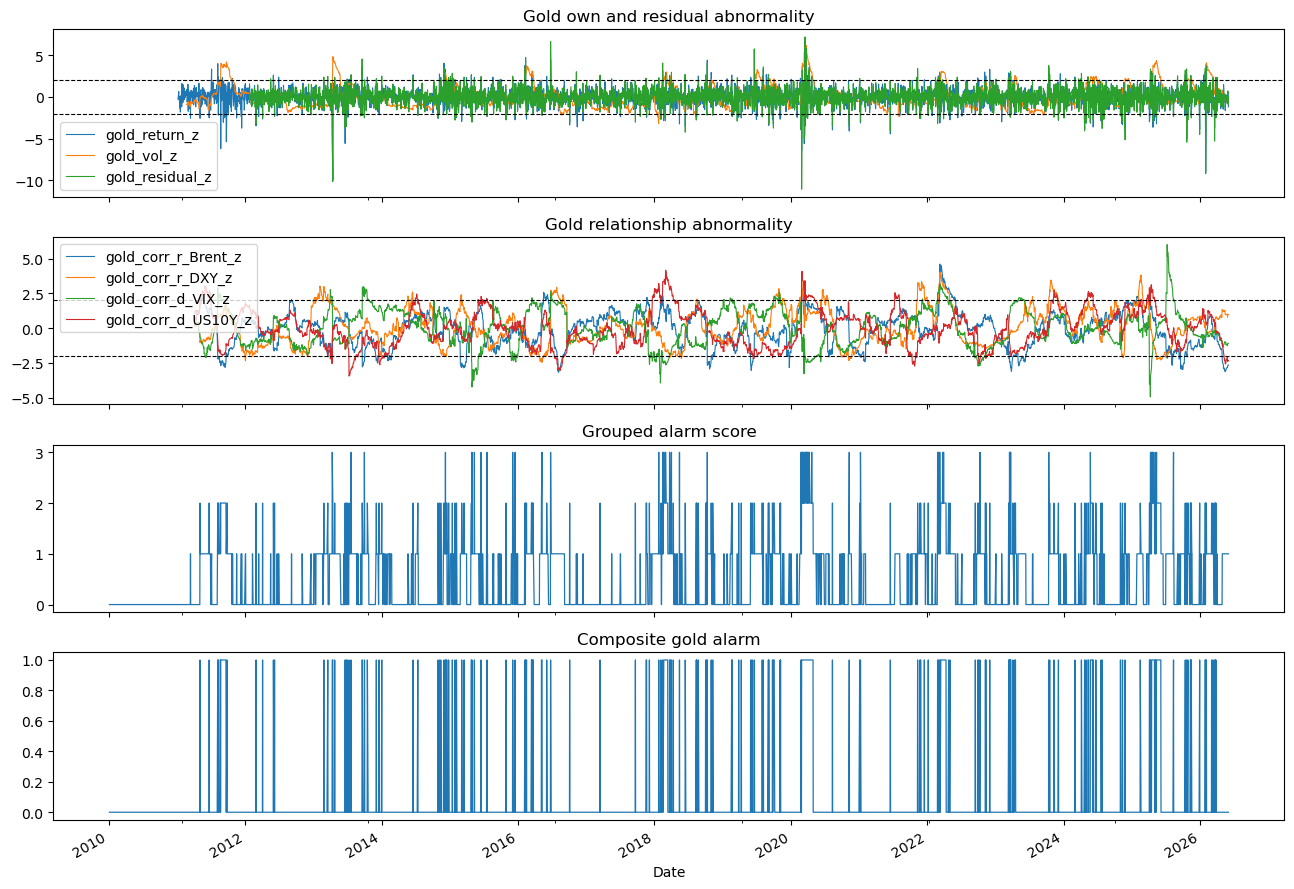

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

signal_components[["gold_return_z", "gold_vol_z", "gold_residual_z"]].plot(ax=axes[0], linewidth=0.8)
axes[0].axhline(THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[0].axhline(-THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Gold own and residual abnormality")

signal_components[corr_z_cols].plot(ax=axes[1], linewidth=0.8)
axes[1].axhline(THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[1].axhline(-THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Gold relationship abnormality")

alarm_frame["alarm_score"].plot(ax=axes[2], linewidth=0.9)
axes[2].set_title("Grouped alarm score")

alarm_frame["gold_alarm"].plot(ax=axes[3], linewidth=0.9)
axes[3].set_title("Composite gold alarm")

plt.tight_layout()


## Step 04 Working Takeaways

- Gold alarm construction uses the core variables only.
- Copper remains outside the primary alarm and can be added later as a robustness-extension conditioning variable.
- The grouped alarm is designed for escalation, not direct loss prediction.
- The next step should connect this alarm to a risk-book VaR/stress-testing layer and evaluate false alarms.

In [9]:
signal_components.to_parquet(PROCESSED_DIR / "gold_signal_components.parquet")
alarm_frame.to_parquet(PROCESSED_DIR / "gold_alarm_frame.parquet")
threshold_summary.to_csv(OUTPUT_DIR / "gold_alarm_threshold_summary.csv", index=False)

print("Saved Step 04 gold alarm outputs to:", OUTPUT_DIR)
print("Signal components:", PROCESSED_DIR / "gold_signal_components.parquet")
print("Alarm frame:", PROCESSED_DIR / "gold_alarm_frame.parquet")


Saved Step 04 gold alarm outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step04
Signal components: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\gold_signal_components.parquet
Alarm frame: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\gold_alarm_frame.parquet


### Step 04 Output Significance

The saved alarm frame is the bridge between market evidence and operational risk management. Later notebooks should not just show the alarm visually; they should test whether it appears before VaR breaches, volatility spikes, or drawdown events.